# Data Analysis: Hybrid vs Midair

This notebook calculates the mean and standard deviation for 'Distance to Centerline' and 'Time Consumption' for each condition.

In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

# Configuration
# Assuming the notebook is placed in 'd:/MagicPenII/Hybrid data/'
BASE_PATH = "."
CONDITIONS = ['haptic', 'midair']

In [2]:
def process_condition(condition_name):
    path = os.path.join(BASE_PATH, condition_name)
    # Match all CSV files in the condition folder
    all_files = glob.glob(os.path.join(path, "*.csv"))
    
    print(f"Found {len(all_files)} files for {condition_name}")
    
    condition_data = []

    for file in all_files:
        try:
            df = pd.read_csv(file)
            
            # Filter for traces that are actually part of the target task
            if 'IsTargetTrace' in df.columns:
                df = df[df['IsTargetTrace'] == True]
            
            if df.empty:
                continue

            # Group by StrokeID to calculate per-stroke metrics
            # We assume a file might contain multiple strokes
            if 'StrokeID' in df.columns:
                grouped = df.groupby('StrokeID')
                
                for stroke_id, group in grouped:
                    # Time Consumption: Max timestamp - Min timestamp
                    # Ensure Timestamp is sorted or act on min/max
                    duration = group['Timestamp'].max() - group['Timestamp'].min()
                    
                    # Mean Distance to Centerline
                    mean_distance = group['DistToCenterline'].mean()
                    
                    condition_data.append({
                        'Condition': condition_name,
                        'File': os.path.basename(file),
                        'StrokeID': stroke_id,
                        'Duration': duration,
                        'MeanDistance': mean_distance
                    })
            else:
                # If no StrokeID, treat the whole file as one trial?
                # Based on user data inspection, StrokeID exists. 
                # But adding fallback just in case.
                duration = df['Timestamp'].max() - df['Timestamp'].min()
                mean_distance = df['DistToCenterline'].mean()
                condition_data.append({
                    'Condition': condition_name,
                    'File': os.path.basename(file),
                    'StrokeID': 'All',
                    'Duration': duration,
                    'MeanDistance': mean_distance
                })
                
        except Exception as e:
            print(f"Error processing {file}: {e}")
            
    return pd.DataFrame(condition_data)

In [3]:
# Aggregate Data
all_results = pd.DataFrame()

for condition in CONDITIONS:
    print(f"Processing {condition}...")
    if os.path.exists(os.path.join(BASE_PATH, condition)):
        df_cond = process_condition(condition)
        all_results = pd.concat([all_results, df_cond], ignore_index=True)
    else:
        print(f"Warning: Folder for {condition} not found.")

print("Processing complete.")
all_results.head()

Processing haptic...
Found 10 files for haptic
Processing midair...
Found 10 files for midair
Processing complete.


,Condition,File,StrokeID,Duration,MeanDistance
0,haptic,1 h.csv,2,2.199129,0.001424
1,haptic,1 h.csv,3,6.697303,0.003250
2,haptic,1 h.csv,4,3.918430,0.002192
3,haptic,1 h.csv,5,2.721300,0.002829
4,haptic,1 h.csv,6,1.676910,0.001108


In [4]:
# Calculate Statistics
summary_stats = all_results.groupby('Condition')[['MeanDistance', 'Duration']].agg(['mean', 'std', 'count'])

print("Summary Statistics (Mean & Std):")
print(summary_stats)

Summary Statistics (Mean & Std):
          MeanDistance                  Duration                
                  mean       std count      mean       std count
Condition                                                       
haptic        0.003801  0.001425   280  4.322200  2.514785   280
midair        0.004469  0.001678   280  2.274221  1.519362   280


C:\Users\32785\AppData\Local\Temp\ipykernel_37080\2198705383.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Condition', y='MeanDistance', data=all_results, palette="Set2")
C:\Users\32785\AppData\Local\Temp\ipykernel_37080\2198705383.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Condition', y='Duration', data=all_results, palette="Set2")


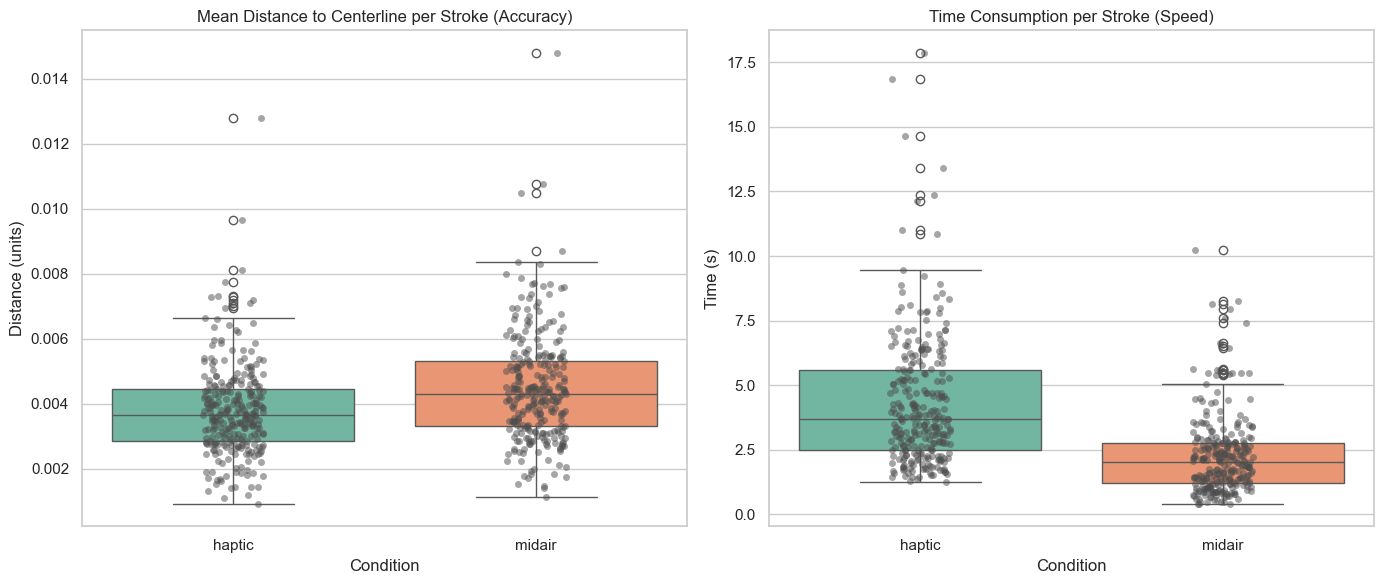

In [5]:
# Visualizations: Boxplots
if not all_results.empty:
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    sns.boxplot(x='Condition', y='MeanDistance', data=all_results, palette="Set2")
    sns.stripplot(x='Condition', y='MeanDistance', data=all_results, color=".3", alpha=0.5)
    plt.title('Mean Distance to Centerline per Stroke (Accuracy)')
    plt.ylabel('Distance (units)')

    plt.subplot(1, 2, 2)
    sns.boxplot(x='Condition', y='Duration', data=all_results, palette="Set2")
    sns.stripplot(x='Condition', y='Duration', data=all_results, color=".3", alpha=0.5)
    plt.title('Time Consumption per Stroke (Speed)')
    plt.ylabel('Time (s)')

    plt.tight_layout()
    plt.show()
else:
    print("No data to visualize.")

### Understanding the Boxplots:
- **Box**: Represents the middle 50% of the data (Interquartile Range, from 25th to 75th percentile).
- **Line in the middle**: The Median value.
- **Whiskers (vertical lines)**: The range of the data, extending up to 1.5x the IQR. Points outside this are considered outliers.
- **Dots**: Individual data points (overlaid to show density).

C:\Users\32785\AppData\Local\Temp\ipykernel_37080\1599853999.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='Condition', y='MeanDistance', data=all_results, ci='sd', capsize=.1, palette="Set2")
C:\Users\32785\AppData\Local\Temp\ipykernel_37080\1599853999.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Condition', y='MeanDistance', data=all_results, ci='sd', capsize=.1, palette="Set2")
C:\Users\32785\AppData\Local\Temp\ipykernel_37080\1599853999.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='Condition', y='Duration', data=all_results, ci='sd', capsize=.1, palette="Set2")
C:\Users\32785\AppData\Local\Temp\ipykernel_37080\1599853999.py:11: FutureWarning: 

Passing `palette` without assigning `hue` 

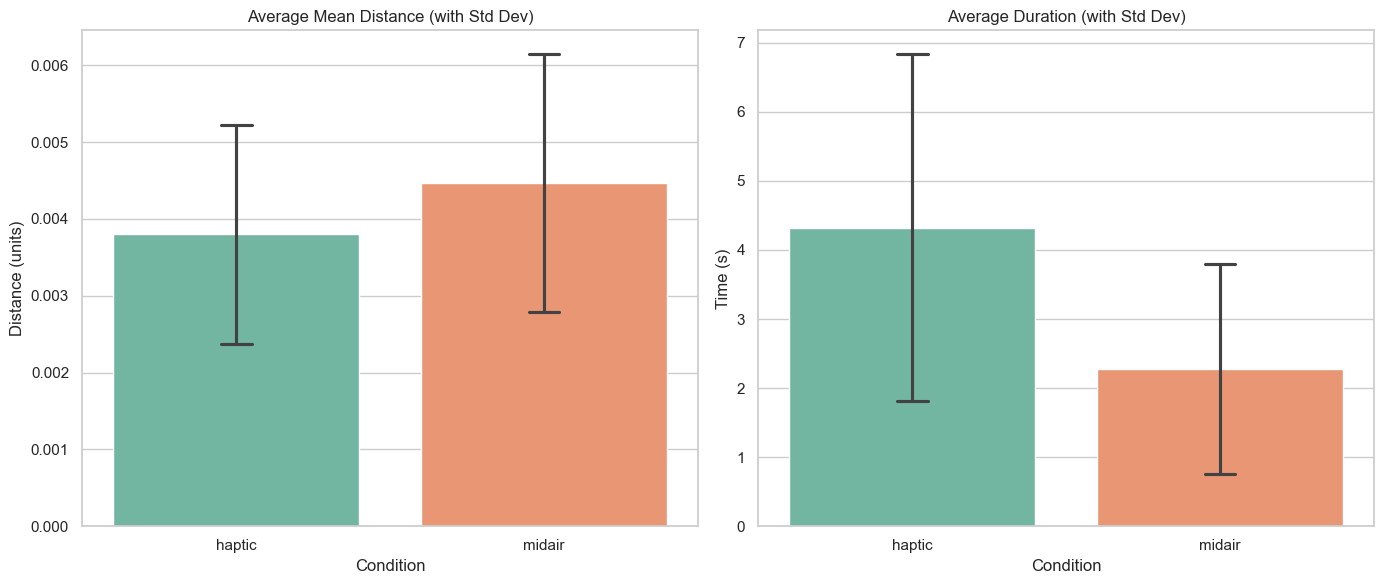

Note: In these bar charts, the black lines on top of the bars represent the Standard Deviation (SD).


In [6]:
# Visualizations: Bar Charts with Standard Deviation
if not all_results.empty:
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    sns.barplot(x='Condition', y='MeanDistance', data=all_results, ci='sd', capsize=.1, palette="Set2")
    plt.title('Average Mean Distance (with Std Dev)')
    plt.ylabel('Distance (units)')

    plt.subplot(1, 2, 2)
    sns.barplot(x='Condition', y='Duration', data=all_results, ci='sd', capsize=.1, palette="Set2")
    plt.title('Average Duration (with Std Dev)')
    plt.ylabel('Time (s)')

    plt.tight_layout()
    plt.show()
    
    print("Note: In these bar charts, the black lines on top of the bars represent the Standard Deviation (SD).")
else:
    print("No data to visualize.")

In [7]:
# Save processed data to CSV for record
all_results.to_csv("processed_analysis_results.csv", index=False)
print("Saved processed results to processed_analysis_results.csv")

Saved processed results to processed_analysis_results.csv
